In [7]:
## Create a vector of the required packages for this analysis
req_packages <- c("cowplot", "ggplot2", "ggpubr", "janitor", "multcompView", "tidyverse", "viridis")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

In [8]:
## load in chromosome bp
chromosome_size <- read_tsv("input/dame_g96.chrom.sizes", col_names = FALSE)
colnames(chromosome_size) <- c("number_chrom", "size_bp")
chromosome_size <- chromosome_size %>%
    filter(grepl("Chr", number_chrom))

head(chromosome_size)

Rows: 6 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,size_bp
<chr>,<dbl>
Chr_2,39200649
Chr_3,27942935
Chr_4,30829601
Chr_5,27587546
Chr_6,1836789
Chr_X,32139017


In [9]:
## load in filtered snpeff results
snpeff_raw <- read_tsv("input/vg_annotated.snpsift_high.vcf", skip = 519) %>%
    janitor::clean_names()
head(snpeff_raw)

Rows: 25798 Columns: 215
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (213): #CHROM, ID, REF, ALT, FILTER, INFO, FORMAT, AA_99_06, BB_05_10, B...
dbl   (2): POS, QUAL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,pos,id,ref,alt,qual,filter,info,format,aa_99_06,⋯,wr_06_18,wr_06_22,wr_06_24,wr_06_40,wr_06_44,ws_07_06,ws_07_10,ws_07_16,ws_07_18,ws_07_20
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29000,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G|frameshift_variant|HIGH|rna-XM_002058356.4|gene-LOC6635204|transcript|rna-XM_002058356.4|protein_coding|1/2|c.170_171delTC|p.Leu57fs|390/851|170/540|57/179||,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439219.2|protein_coding||c.-4919_-4918delTC|||||3576|,G|upstream_gene_variant|MODIFIER|rna-XM_002058355.4|gene-Pebp1|transcript|rna-XM_002058355.4|protein_coding||c.-696_-695delTC|||||653|,G|upstream_gene_variant|MODIFIER|rna-XM_002058358.4|gene-Rpn7|transcript|rna-XM_002058358.4|protein_coding||c.-2960_-2959delGA|||||2848|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439221.2|protein_coding||c.-4919_-4918delTC|||||3578|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439223.2|protein_coding||c.-4919_-4918delTC|||||3577|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439225.2|protein_coding||c.-4919_-4918delTC|||||3577|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439220.2|protein_coding||c.-4919_-4918delTC|||||3576|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439224.2|protein_coding||c.-4919_-4918delTC|||||3576|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439226.2|protein_coding||c.-4919_-4918delTC|||||3582|,G|upstream_gene_variant|MODIFIER|rna-XM_032439221.2|gene-Nrx-1|transcript|rna-XM_032439227.2|protein_coding||c.-4919_-4918delTC|||||3584|,G|downstream_gene_variant|MODIFIER|rna-XM_032439231.1|gene-LOC6635191|transcript|rna-XM_032439231.1|protein_coding||c.*1345_*1346delGA|||||1318|,G|downstream_gene_variant|MODIFIER|rna-XM_002058357.4|gene-AP-2mu|transcript|rna-XM_002058357.4|protein_coding||c.*1179_*1180delTC|||||695|,G|downstream_gene_variant|MODIFIER|rna-XM_015169381.3|gene-LOC6635208|transcript|rna-XM_015169381.3|protein_coding||c.*4543_*4544delTC|||||4337|;LOF=(rna-XM_002058356.4|gene-LOC6635204|1|1.00)",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:5:5,0:-1.6658,-2.41599,-12.4051:7:-1.26222:3.39241:5",⋯,"0/0:8:8,0:-2.32222,-4.16732,-20.1499:18:-1.1128:3.55696:8","0/0:1:1,0:-3.39106,-4.13913,-6.13696:7:-1.26448:11.2532:1","0/0:1:1,0:-1.19903,-1.52583,-3.52366:3:-1.4879:4.26582:1","0/0:11:11,0:-3.06167,-5.35478,-27.3309:22:-1.10369:5.12658:11","0/0:9:9,0:-2.58275,-4.33962,-22.3201:17:-1.11597:4.55696:9","1/1:13:0,13:-31.0442,-5.0724,-1.98399:30:-1.09943:10.0506:13","0/0:14:14,0:-2.5401,-6.07565,-34.0452:35:-1.0989:7.82278:14","1/0:8:1,7:-15.7366,-2.4028,-2.80758:4:-1.43061:9:1","0/0:0:0,0:-2.23195,-2.23195,-2.23195:0:-2.19723:5.13924:0","1/1:0:0,0:-1.93509,-1.93509,-1.93509:0:-2.19723:4.4557:0"
Chr_2,855687,>54464>54467,A,G,9.54243,lowad,"DP=0;AT=>54464>54466>54467,>54464>54465>54467;AF=1;ANN=G|splice_donor_variant&intron_variant|HIGH|rna-XM_032438902.2|gene-TkR99D|transcript|rna-XM_032438902.2|protein_coding|1/9|c.-107+1T>C||||||,G|intron_variant|MODIFIER|rna-XM_032438902.2|gene-TkR99D|transcript|rna-XM_032438899.2|protein_coding|3/11|c.-107+323T>C||||||,G|intron_variant|MODIFIER|rna-XM_032438902.2|gene-TkR99D|transcript|rna-XM_032438900.2|protein_coding|2/10|c.-107+323T>C||||||,G|intron_variant|MODIFIER|rna-XM_032438902.2|gene-TkR99D|transcript|rna-XM_032438903.2|protein_coding|3/12|c.-107+323T>C||||||;LOF=(rna-XM_032438902.2|gene-TkR99D|4|0.25)",GT:DP:AD:GL:GQ:GP:XD:MAD,"1/1:0:0,0:-3.2386,-3.2386,-3.2386:0:-2.19723:7.45714:0",⋯,"1/1:0:0,0:-4.5539,-4.5539,-4.5539:0:-2.19723:10.4857:0","1/1:0:0,0:-5.08126,-5.08126,-5.08126:0:-2.19723:11.7:0","1/1:0:0,0:-4.33675,-4.33675,-4.33675:0:

In [10]:
## separate the results information wider
snpeff <- snpeff_raw %>%
    # filter(!grepl("intergenic_region", info)) %>%
    pivot_longer(10:ncol(snpeff_raw), names_to = "strain", values_to = "presence") %>%
    # separate_wider_delim(info, delim = ";", names = c("depth", "read_transversal", "info")) %>%
    separate_wider_delim(info, delim = "|", too_many = "merge",
                         names = c("annotation", "annotation_impact", "gene_name", "gene_id", "feature_type", 
                                   "feature_id", "transcript_biotype", "rank", "HGVS.c", "HGVS.p", 
                                   "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
                                   "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
    separate_wider_delim(presence, delim = ":", too_many = "merge", 
                         names = c("genotype", "read_depth", "ref.depth_alt.depth", "genotype_likelihood", 
                                   "phred", "genotype_probability", "expected_depth", 
                                   "minimum_site_allele_depth")) %>%
    separate_longer_delim(annotation_impact, delim = "&")
head(snpeff)

number_chrom,pos,id,ref,alt,qual,filter,annotation,annotation_impact,gene_name,⋯,format,strain,genotype,read_depth,ref.depth_alt.depth,genotype_likelihood,phred,genotype_probability,expected_depth,minimum_site_allele_depth
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,aa_99_06,0/0,5,"5,0","-1.6658,-2.41599,-12.4051",7,-1.26222,3.39241,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_10,0/0,3,"3,0","-1.15467,-1.58018,-7.57366",4,-1.41736,3.56962,3
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_18,0/0,5,"5,0","-1.35211,-2.27185,-12.261",9,-1.21221,5.01266,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_36,0/0,11,"11,0","-3.88771,-6.0703,-28.0464",21,-1.10516,3.97468,11
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_44,0/0,15,"15,0","-2.1338,-5.78636,-35.7538",36,-1.09883,11.2278,15
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_46,1/0,7,"3,4","-9.19754,-1.71297,-6.9283",52,-1.09862,4.3038,3


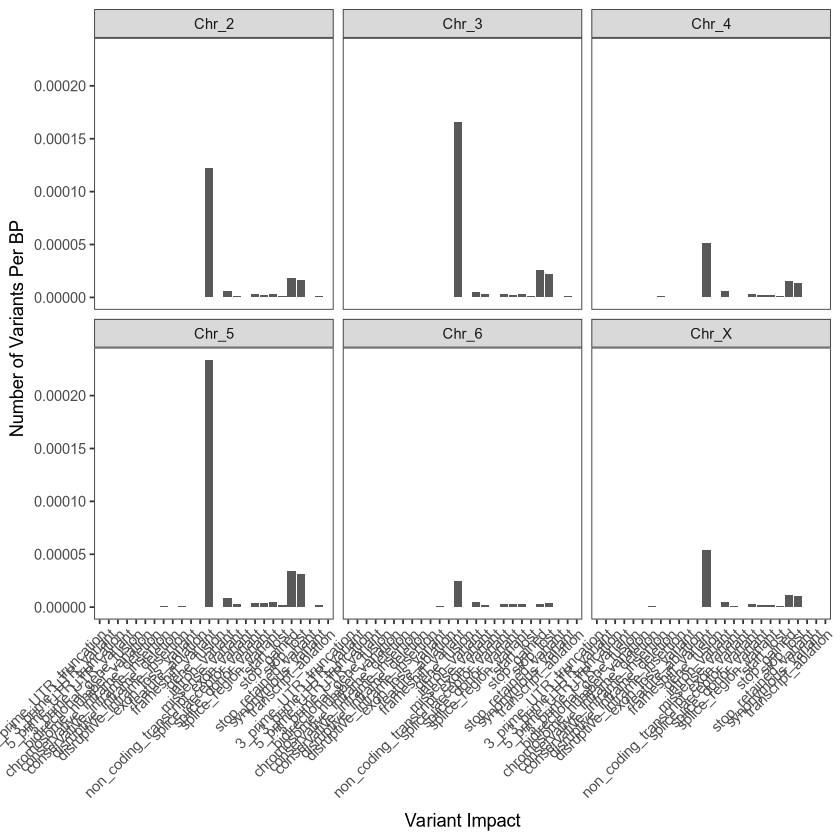

In [11]:
## plot the number of variants with each impact, per chromosome
impact_chromosome <- snpeff %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, annotation_impact) %>%
    unique() %>%
    group_by(number_chrom, annotation_impact) %>%
    count() %>%
    left_join(chromosome_size, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(normal = n/size_bp) %>%
    ggplot(aes(x = annotation_impact, y = normal)) +
        geom_bar(stat = "identity") +
        labs(x = "Variant Impact", y = "Number of Variants Per BP") +
        theme_bw() +
        theme(panel.grid = element_blank(),
              axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
        facet_wrap(~ number_chrom)
impact_chromosome

In [12]:
ggsave("figures/highimpact_variant_chromosome_bp.png", impact_chromosome, height = 10, width = 15)

## Calculate heterozygosity for each population

In [13]:
## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv") %>%
    janitor::clean_names() %>%
    filter(!is.na(latitude)) %>%
    mutate(strain_id = tolower(strain_id),
           strain_id = str_replace_all(strain_id, "\\.", "_")) %>%
    separate_wider_delim(strain_id, delim = "_", names = c("location", "female", "number"), too_few = "align_start", too_many = "drop")
head(metadata)

Rows: 294 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): species_group, Species, strain_ID, strain_type, Genotype, label, s...
dbl  (5): year, latitude, longitude, water_distance_mi, riparian_year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


species_group,species,location,female,number,strain_type,genotype,label,year,slot,⋯,state,country,latitude,longitude,sequencing,wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,aa,99,06,wild-type,wt,NA,1999,A5-5,⋯,AR,USA,35.28654,-91.38307,nextera_2020,No,0.08,Riverine,NA,1980
virilis,D. americana,bb,05,10,wild-type,wt,NA,2005,A6-1,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,18,wild-type,wt,NA,2005,A6-2,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,36,wild-type,wt,NA,2005,A6-3,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,red,mutant,red,NA,2005,A6-4,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,44,wild-type,wt,NA,2005,A6-5,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980


`mutate_all()` ignored the following grouping variables:
• Columns `number_chrom`, `pos`, `alt`, `location`, `genotype`
ℹ Use `mutate_at(df, vars(-group_cols()), myoperation)` to silence the message.
Warning message in left_join(., het_pop, by = "location"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


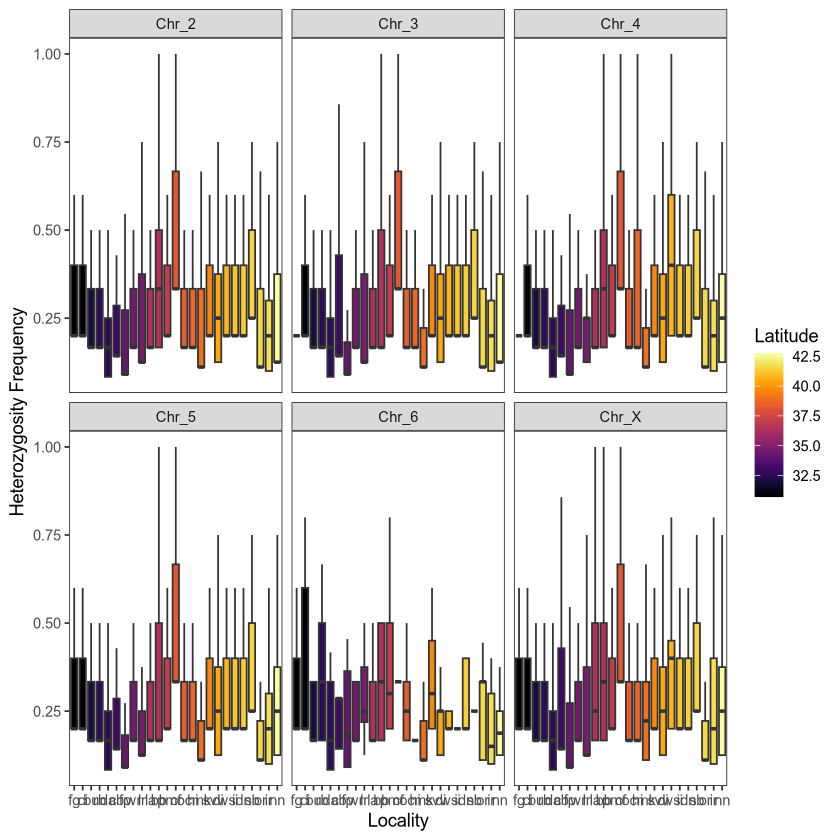

In [14]:
## count the total number of strains per population 
strain_pop <- snpeff %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location) %>%
    count() %>%
    rename(total = n)

## count the number of heterozygotes
het_pop <- snpeff %>%
    filter(grepl("Chr", number_chrom) & (genotype == "1/0" | genotype == "0/1")) %>%
    # filter(grepl("stop", annotation_impact)) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location, genotype) %>%
    count() %>%
    mutate_all(~replace_na(., 0)) %>%
    left_join(strain_pop, by = c("number_chrom", "pos", "alt", "location")) %>%
    mutate(het_freq = n/total)

## plot heterozygosity
het_graph <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location") %>%
    filter(total > 2) %>%
    na.omit() %>%
    ggplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude)) +
    geom_boxplot(outlier.shape = NA) +
    labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
    scale_fill_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank(),
          legend.positino = "bottom") +
    facet_wrap(~number_chrom)

het_graph

In [15]:
ggsave("figures/heterozygosity_pop.png", het_graph, height = 12, width = 25)

Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


Warning message in left_join(., het_pop_groups, by = "location"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 5579 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


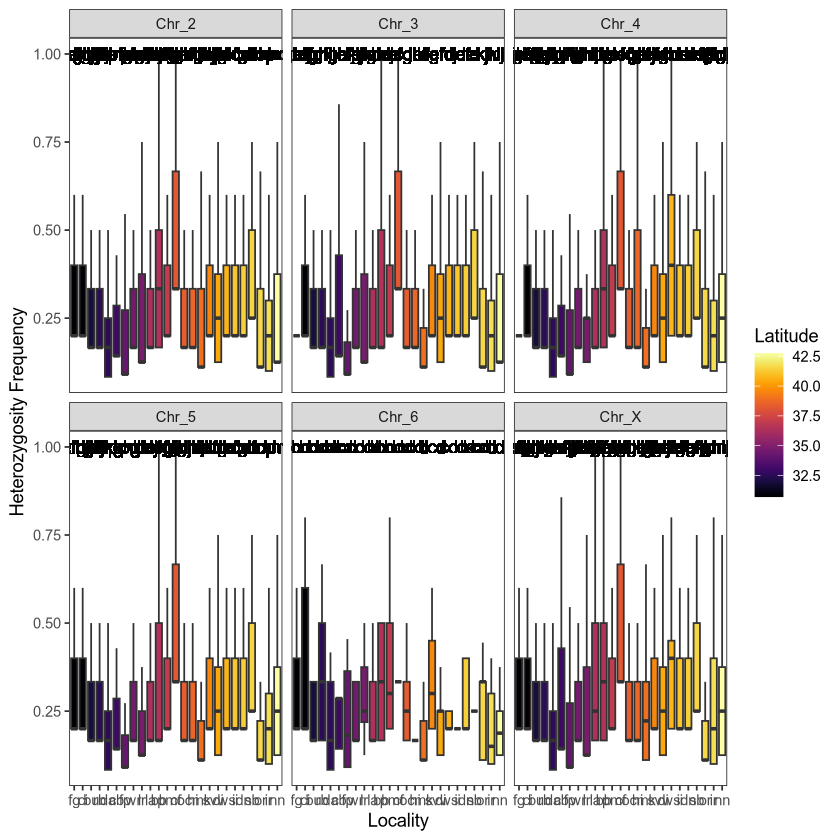

In [16]:
## determine if some populations have heterozygosity frequency that deviates from the chromosome average
number_chrom <- unique(het_pop$number_chrom)

het_pop_groups <- matrix(data = NA, nrow = 1, ncol = ncol(het_pop) + 1,
                         dimnames = list(c("remove"),
                                         c("location", "group", colnames(het_pop)[-4])))

for (i in number_chrom) {

    ## filter the data frame only for the chromosome of interest
    het_freq_sub <- het_pop %>%
        filter(number_chrom == i)

    ## perform anova
    het_freq_anova <- aov(het_freq ~ location, data = het_freq_sub)

    ## perform post hoc test
    het_freq_tukey <- TukeyHSD(het_freq_anova)

    ## group the chromosomes based on Tukey test
    het_freq_groups <- multcompLetters4(het_freq_anova, het_freq_tukey)
    het_pop_groups_sub <- as.data.frame.list(het_freq_groups$location) %>%
        mutate(group = Letters) %>%
        select(group) %>%
        rownames_to_column("location") %>%
        mutate(number_chrom = paste(i)) %>%
        full_join(het_pop, by = c("location", "number_chrom"))

    ## add chromosome to group data frame
    het_pop_groups <- rbind(het_pop_groups, het_pop_groups_sub)

}

## add groups to plot
het_graph_groups <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop_groups, by = "location") %>%
    filter(total > 2) %>%
    na.omit() %>%
    ggplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude)) +
    geom_boxplot(outlier.shape = NA) +
    geom_text(aes(label = group, y = 1)) +
    labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
    scale_fill_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank(),
          legend.positino = "bottom") +
    facet_wrap(~number_chrom)

het_graph_groups

In [17]:
ggsave("figures/heterozygosity_pop_group.png", het_graph_groups, height = 12, width = 25)

Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


### Calculate if heterozygosity happens higher than chance for each population for each chromosome

In [18]:
## create empty data frame to populate
het_pop_ttest <- matrix(data = NA, nrow = 1, ncol = 3,
                        dimnames = list(c("remove"),
                                        c("number_chrom", "location", "p_value"))) %>%
                as.data.frame()

## calculate how much the heterozygosity frequency deviates from expected for each location per chromosome
for (i in number_chrom) {
    
    ## pull the list of heterozygosity frequencies for the entire chromosome, across populations
    y <-  het_pop %>%
        filter(number_chrom == i) %>%
        pull("het_freq")

    for (j in unique(het_pop$location)) {    
        
        ## pull the heterozygosity frequencies for the location on chromosome
        x <- het_pop %>%
            filter(number_chrom == i & location == j) %>%
            pull("het_freq")
            
        if (length(x) > 2) {        
            ## run the t-test
            test <- t.test(x = x, y = y, alternative = "greater")

            ## populate the data frame
            het_pop_ttest <- het_pop_ttest %>%
                add_row(number_chrom = i, location = j, p_value = test$p.value)

        }
    }
}

## filter out the removed row
het_pop_ttest <- het_pop_ttest %>%
    na.omit()
head(het_pop_ttest)

,number_chrom,location,p_value
,<chr>,<chr>,<dbl>
...2,Chr_2,bb,0.9999924
...3,Chr_2,bu,1.0000000
...4,Chr_2,cb,1.0000000
...5,Chr_2,da,1.0000000
...6,Chr_2,di,1.0000000
...7,Chr_2,fp,1.0000000


Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


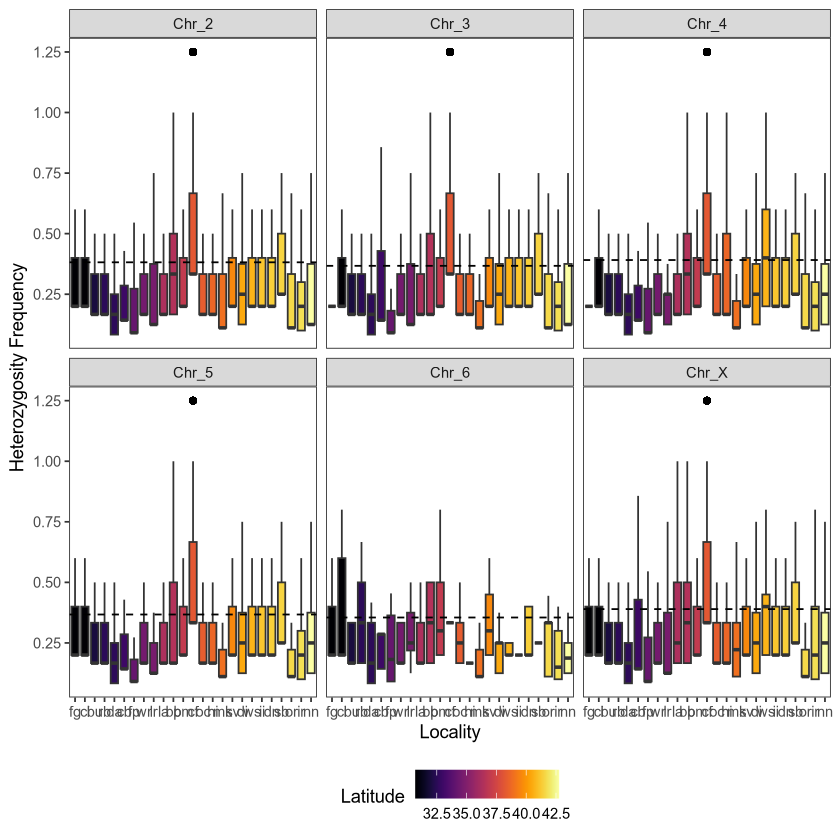

In [19]:
## calculate the average heterozygosity per chromosome
chrom_het_avg <- het_pop %>%
    group_by(number_chrom) %>%
    summarize(probability = mean(het_freq))

## plot the number of populations that deviate from the chromosomal mean
het_graph_deviate <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 2) %>%
    na.omit() %>%
    left_join(het_pop_ttest, by = c("number_chrom", "location"), relationship = "many-to-many") %>%
    left_join(chrom_het_avg, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(deviate = case_when(p_value < 0.05 ~ 1.25,
                               TRUE ~ NA)) %>%
    ggplot() +
        geom_boxplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude), outlier.shape = NA) +
        geom_hline(aes(yintercept = probability), linetype = "dashed") +
        geom_point(aes(x = fct_reorder(location, latitude), y = deviate)) +
        labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
        scale_fill_viridis(option = "B") +
        theme_bw() +
        theme(panel.grid = element_blank(),
            legend.position = "bottom") +
        facet_wrap(~number_chrom)
het_graph_deviate

In [20]:
ggsave("figures/heterozygosity_pop_deviate.png", het_graph_deviate, height = 6, width = 12)

Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


## Calculate high impact variant frequency per population

In [21]:
## load in the strain list
strain_list <- read_tsv("input/pops_origin.tsv", col_names = FALSE) %>%
    mutate_all(., tolower)
colnames(strain_list) <- c("strain", "location")
head(strain_list)

Rows: 412 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,location
<chr>,<chr>
aa_99_06,aa
aa_99_06,aa
bb_05_10,bb
bb_05_10,bb
bb_05_18,bb
bb_05_18,bb


In [22]:
## calculate the number of alleles per population
strain_number <- strain_list %>%
    group_by(location) %>%
    count() %>%
    rename(total = n) %>%
    mutate(total = total*2)

## calculate the frequency of each allele in each population
snpeff_pop <- snpeff %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, genotype, location) %>%
    count() %>%
    rename(presence = n) %>%
    mutate(presence = case_when(genotype == "1/1" ~ presence*2,
                               genotype == "0/1" ~ presence,
                               TRUE ~ 0)) %>%
    group_by(number_chrom, pos, alt, location) %>%
    reframe(presence_total = sum(presence)) %>%
    right_join(strain_number, by = "location") %>%
    mutate(total = case_when(presence_total > total ~ presence_total,
                             TRUE ~ total),
           ratio = presence_total/total)

head(snpeff_pop)

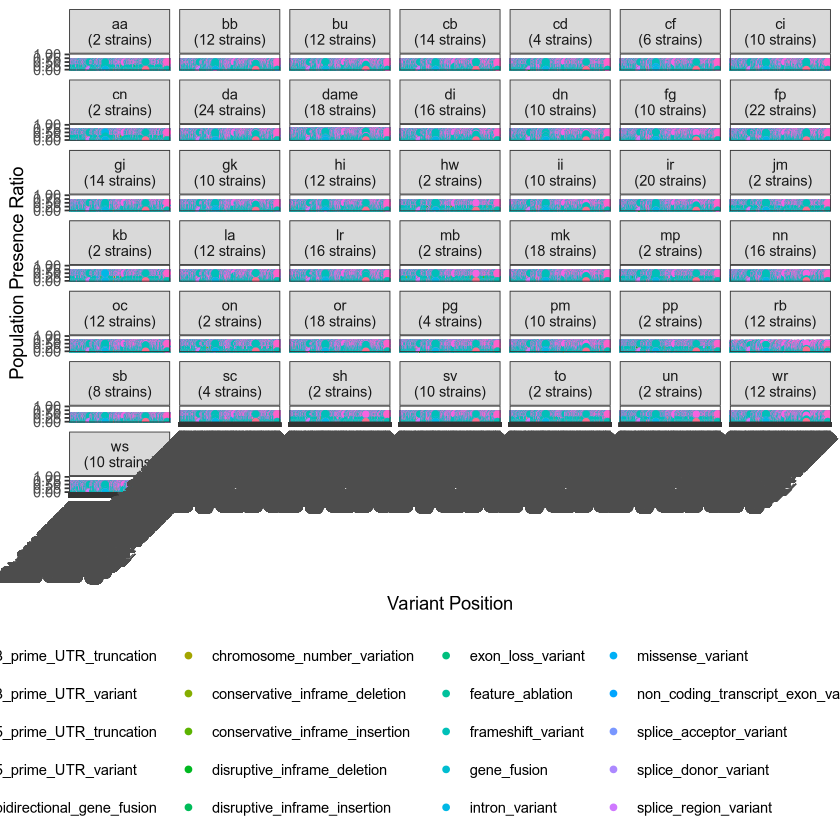

In [ ]:
## add annotation information to population frequency
impact_pop <- snpeff %>%
    select(number_chrom, pos, annotation_impact) %>%
    unique() %>%
    right_join(snpeff_pop, by = c("number_chrom", "pos"), relationship = "many-to-many")

## plot the frequency of each allele per population
pop_graph <- impact_pop %>%
    mutate(position = paste(number_chrom, pos),
           name = paste0(location, "\n(", total/2, " strains)")) %>%
    filter(annotation_impact != "synonymous_variant") %>%
    ggplot(aes(x = position, y = ratio, color = annotation_impact), alpha = 0.5) +
        geom_point() +
        ylim(0, 1) +
        labs(x = "Variant Position", y = "Population Presence Ratio",
             color = "Variant Impact") +
        theme_bw() +
        theme(panel.grid = element_blank(),
              axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              legend.position = "bottom") +
        facet_wrap(~name)
pop_graph

In [ ]:
ggsave("figures/highimpact_freq_pop.png", pop_graph, height = 12, width = 25)

In [ ]:
## determine if there is a difference in number of high impact mutation per chromosome
impact_lat_pop <- metadata %>%
    select(location, latitude) %>%
    unique() %>%
    left_join(impact_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 5)

chrom_anova <- aov(ratio ~ number_chrom + annotation_impact, data = impact_lat_pop)
summary(chrom_anova)

                      Df Sum Sq Mean Sq F value Pr(>F)    
number_chrom           5    556   111.2    3287 <2e-16 ***
annotation_impact     25   8598   343.9   10165 <2e-16 ***
Residuals         808413  27350     0.0                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

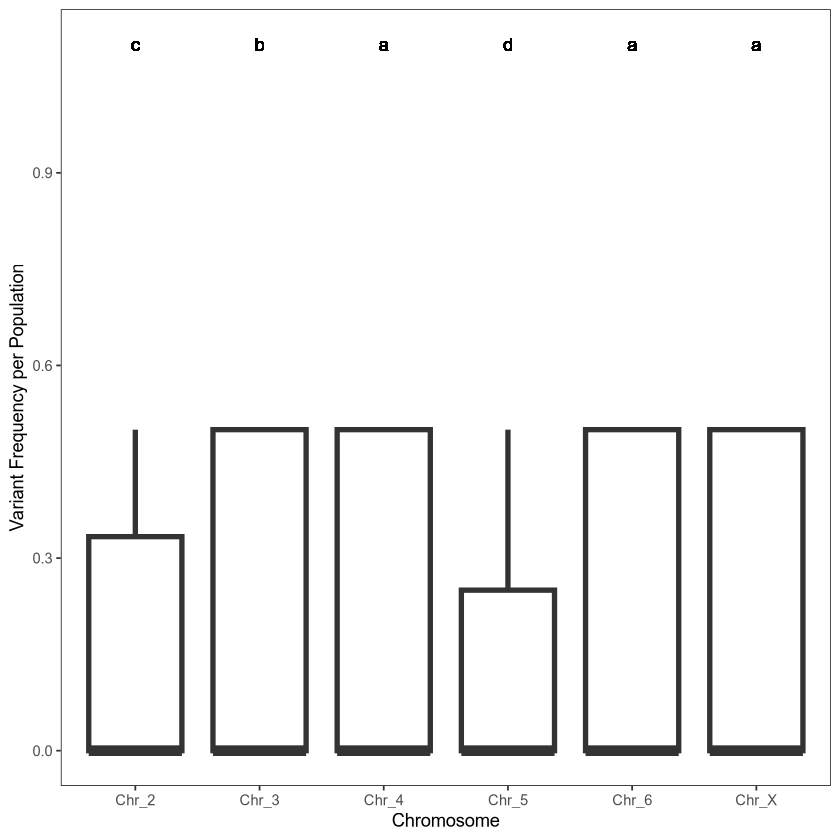

In [ ]:
## perform post hoc test
chrom_tukey <- TukeyHSD(chrom_anova)

## group the chromosomes based on Tukey test
chrom_groups <- multcompLetters4(chrom_anova, chrom_tukey)
impact_lat_pop_groups <- as.data.frame.list(chrom_groups$number_chrom) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("number_chrom") %>%
    full_join(impact_lat_pop, by = "number_chrom", relationship = "many-to-many")

## add groups to plot
impact_lat_pop_box <- impact_lat_pop_groups %>%
    ggplot(aes(x = number_chrom, y = ratio)) +
    # geom_jitter(aes(color = latitude), alpha = 0.1) +
    geom_boxplot(fill = NA, linewidth = 1.5) +
    geom_text(aes(label = group, y = 1.1)) +
    labs(x = "Chromosome", y = "Variant Frequency per Population",
         color = "Population Latitude") +
    scale_color_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank())
impact_lat_pop_box

In [ ]:
ggsave("figures/highimpact_freq_chrom.png", impact_lat_pop_box, height = 12, width = 25)

In [ ]:
## determine correlation between latitude and theta
ratio_lat <- impact_lat_pop %>%
    ungroup() %>%
    select(latitude, ratio) %>%
    unique()

cor.test(ratio_lat$latitude, ratio_lat$ratio, method = "pearson")


	Pearson's product-moment correlation

data:  ratio_lat$latitude and ratio_lat$ratio
t = -0.079226, df = 367, p-value = 0.9369
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.10618273  0.09799787
sample estimates:
         cor 
-0.004135535 


In [ ]:
## calculate correlation of theta and latitude for each chromosome
number_chrom <- unique(impact_lat_pop$number_chrom)
ratio_lat_mx <- matrix(data = NA, nrow = length(number_chrom), ncol = 2, 
       dimnames = list(c(number_chrom),
                       c("correlation", "pvalue")))

for (i in number_chrom) {

    ratio_lat_chr <- impact_lat_pop %>%
        ungroup() %>%
        filter(number_chrom == i) %>%
        select(latitude, ratio) %>%
        unique
    correlation <- cor.test(ratio_lat_chr$latitude, ratio_lat_chr$ratio, method = "pearson")
    ratio_lat_mx[[i, "correlation"]] <- correlation$estimate
    ratio_lat_mx[[i, "pvalue"]] <- correlation$p.value
}

ratio_lat_mx

,correlation,pvalue
Chr_2,-0.007543401,0.8853289
Chr_3,-0.001017684,0.9844772
Chr_4,-0.007216415,0.8920727
Chr_5,-0.001668366,0.9745550
Chr_6,0.039506639,0.5815044
Chr_X,0.006021767,0.9084705


In [ ]:
## calculate the variance of allele frequency between populations, by chromosome
impact_lat_var <- impact_lat_pop %>%
    group_by(number_chrom, location, latitude) %>%
    summarize(frequency_variance = var(ratio))

chrom_var_anova <- aov(frequency_variance ~ number_chrom, data = impact_lat_var)
summary(chrom_var_anova)

`summarise()` has grouped output by 'number_chrom', 'location'. You can
override using the `.groups` argument.


              Df  Sum Sq   Mean Sq F value Pr(>F)    
number_chrom   5 0.00392 0.0007841   33.42 <2e-16 ***
Residuals    162 0.00380 0.0000235                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

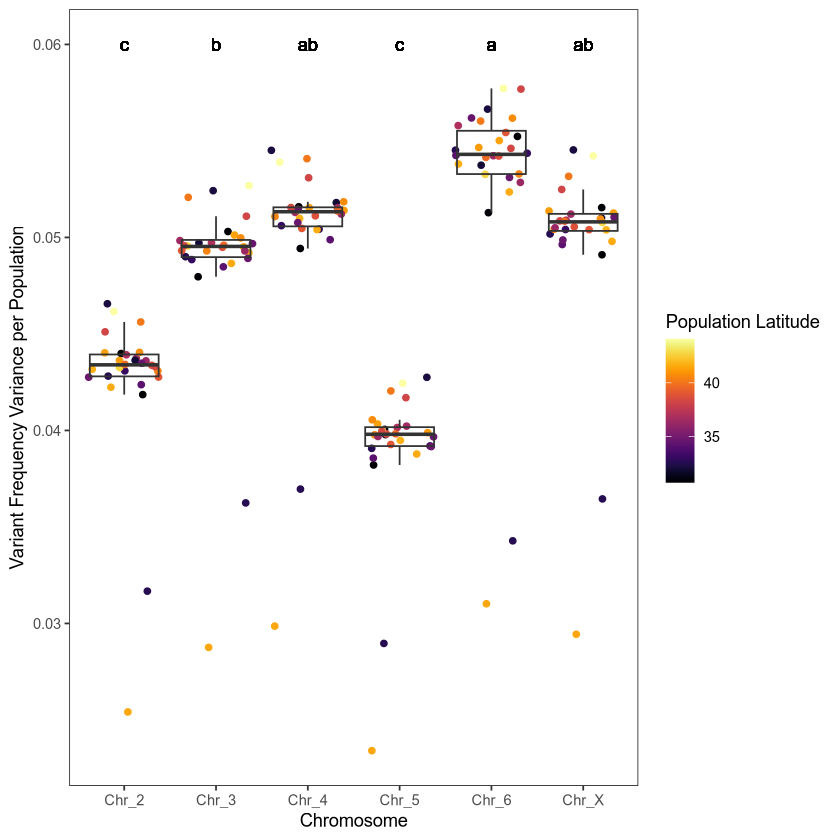

In [ ]:
## perform post hoc test
chrom_var_tukey <- TukeyHSD(chrom_var_anova)

## group the chromosomes based on Tukey test
chrom_var_groups <- multcompLetters4(chrom_var_anova, chrom_var_tukey)
impact_lat_var_groups <- as.data.frame.list(chrom_var_groups$number_chrom) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("number_chrom") %>%
    full_join(impact_lat_var, by = "number_chrom", relationship = "many-to-many")

## add groups to plot
impact_lat_var_box <- impact_lat_var_groups %>%
    ggplot(aes(x = number_chrom, y = frequency_variance)) +
    geom_jitter(aes(color = latitude)) +
    geom_boxplot(fill = NA, outlier.shape = NA) +
    geom_text(aes(label = group, y = 0.06)) +
    labs(x = "Chromosome", y = "Variant Frequency Variance per Population",
         color = "Population Latitude") +
    scale_color_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank())
impact_lat_var_box

In [ ]:
ggsave("figures/highimpact_freq_var_chrom.png", impact_lat_var_box, height = 6, width = 12)

In [ ]:
cor.test(impact_lat_var$frequency_variance, impact_lat_var$latitude, method = "pearson")


	Pearson's product-moment correlation

data:  impact_lat_var$frequency_variance and impact_lat_var$latitude
t = 0.17586, df = 166, p-value = 0.8606
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1380466  0.1647178
sample estimates:
       cor 
0.01364843 


## Correlate allele frequency with latitude

In [ ]:
## create matrix of allele frequency with latitude, by impact
latitude_impact_freq <- impact_lat_pop %>%
    group_by(location, latitude, annotation_impact) %>%
    reframe(ratio = max(ratio)) %>%
    select(-location) %>%
    pivot_wider(names_from = annotation_impact, values_from = ratio) %>%
    mutate_all(replace_na, 0)

impacts <- colnames(latitude_impact_freq)[2:ncol(latitude_impact_freq)]

## Calculate theta for high impact variants

In [ ]:
## save the total number of SNPs
total_snp <- 4557268

In [ ]:
## get the number of variant sites
chrom_loc_segregating <- snpeff %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "line"), too_few = "align_start") %>%
    group_by(number_chrom, pos, genotype, location) %>%
    count() %>%
    pivot_wider(names_from = genotype, values_from = n) %>%
    janitor::clean_names() %>%
    mutate(segregating = case_when(is.na(x0_0) & is.na(x0_1) & is.na(x1_0) ~ 0,
                                   is.na(x1_1) & is.na(x0_1) & is.na(x1_0) ~ 0,
                                   TRUE ~ 1)) %>%
    group_by(number_chrom, location) %>%
    reframe(num_segregating = sum(segregating)) %>%
    left_join(chromosome_size, by = "number_chrom") %>%
    mutate(reg_segregating = num_segregating/size_bp)

head(chrom_loc_segregating)

number_chrom,location,num_segregating,size_bp,reg_segregating
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Chr_2,aa,134,39200649,3.418311e-06
Chr_2,bb,1030,39200649,2.627508e-05
Chr_2,bu,1047,39200649,2.670874e-05
Chr_2,cb,1180,39200649,3.010154e-05
Chr_2,cd,503,39200649,1.283142e-05
Chr_2,cf,767,39200649,1.956600e-05


In [ ]:
## create function to calculate harmonic number
harmonic_number <- function(n) {
    
    Hn <- sum(1/seq(1:n))
    return(Hn)

}

## calculate theta
theta <- strain_number %>%
    mutate(total = total/2) %>%
    filter(total > 3) %>%
    left_join(chrom_loc_segregating, by = "location") %>%
    mutate(harmonic = harmonic_number(total),
           theta = reg_segregating/harmonic) %>%
    inner_join(metadata, by = "location", relationship = "many-to-many") %>%
    select(location, latitude, number_chrom, theta)

head(theta)

Warning message:
“There were 31 warnings in `mutate()`.
The first warning was:
ℹ In argument: `harmonic = harmonic_number(total)`.
ℹ In group 1: `location = "bb"`.
Caused by warning in `1:n`:
! numerical expression has 6 elements: only the first used
ℹ Run `dplyr::last_dplyr_warnings()` to see the 30 remaining warnings.”


location,latitude,number_chrom,theta
<chr>,<dbl>,<chr>,<dbl>
bb,36.46119,Chr_2,8.467061e-06
bb,36.46119,Chr_2,8.467061e-06
bb,36.46119,Chr_2,8.467061e-06
bb,36.46119,Chr_2,8.467061e-06
bb,36.46119,Chr_2,8.467061e-06
bb,36.46119,Chr_2,8.467061e-06


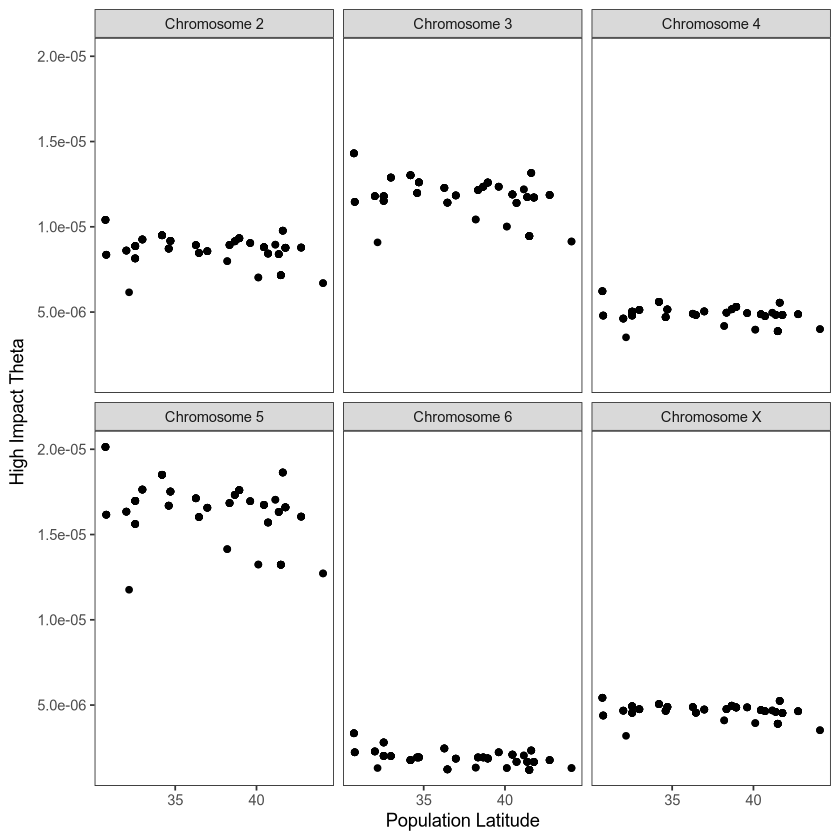

In [ ]:
## plot theta with latitude
theta_lat_point <- theta %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = latitude, y = theta)) +
        geom_point() +
        labs(x = "Population Latitude", y = "High Impact Theta") +
        theme_bw() +
        theme(panel.grid = element_blank()) +
        facet_wrap(~number_chrom)
theta_lat_point

In [ ]:
ggsave("figures/highimpact_theta_lat.png", theta_lat_point, height = 12, width = 25)

In [ ]:
## determine correlation between latitude and theta
theta_lat <- theta %>%
    ungroup() %>%
    select(latitude, theta) %>%
    unique()

cor.test(theta_lat$latitude, theta_lat$theta, method = "pearson")


	Pearson's product-moment correlation

data:  theta_lat$latitude and theta_lat$theta
t = -0.58052, df = 166, p-value = 0.5624
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1950916  0.1071285
sample estimates:
        cor 
-0.04501139 


In [ ]:
## calculate correlation of theta and latitude for each chromosome
number_chrom <- unique(theta$number_chrom)
theta_lat_mx <- matrix(data = NA, nrow = length(number_chrom), ncol = 2, 
       dimnames = list(c(number_chrom),
                       c("correlation", "pvalue")))

for (i in number_chrom) {

    theta_lat_chr <- theta %>%
        ungroup() %>%
        filter(number_chrom == i) %>%
        select(latitude, theta) %>%
        unique
    correlation <- cor.test(theta_lat_chr$latitude, theta_lat_chr$theta, method = "pearson")
    theta_lat_mx[[i, "correlation"]] <- correlation$estimate
    theta_lat_mx[[i, "pvalue"]] <- correlation$p.value
}

theta_lat_mx

,correlation,pvalue
Chr_2,-0.1794517,0.36086172
Chr_3,-0.2662681,0.17081318
Chr_4,-0.2233541,0.25324611
Chr_5,-0.2430705,0.21263147
Chr_6,-0.4662553,0.01238846
Chr_X,-0.1750248,0.37302394


In [ ]:
## determine if there is a difference in theta by chromosome
theta_chrom <- aov(theta ~ number_chrom, data = theta)
summary(theta_chrom)

              Df    Sum Sq   Mean Sq F value Pr(>F)    
number_chrom   5 2.317e-08 4.633e-09    6142 <2e-16 ***
Residuals    936 7.060e-10 1.000e-12                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

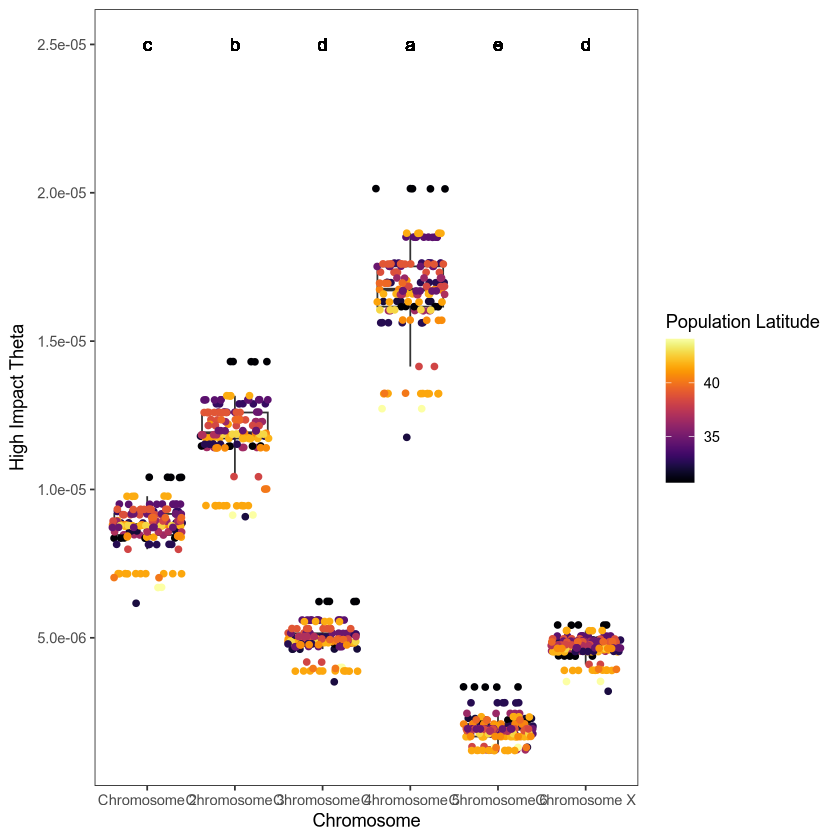

In [ ]:
## perform post hoc test
theta_tukey <- TukeyHSD(theta_chrom)

## group the chromosomes based on Tukey test
theta_chrom_groups <- multcompLetters4(theta_chrom, theta_tukey)
theta_groups <- as.data.frame.list(theta_chrom_groups$number_chrom) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("number_chrom") %>%
    full_join(theta, by = "number_chrom", relationship = "many-to-many")

## plot box plot
theta_box <- theta_groups %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom, y = theta)) +
        geom_boxplot(outlier.shape = NA) +
        geom_jitter(aes(color = latitude)) +
        geom_text(aes(label = group, y = 0.000025)) +
        labs(x = "Chromosome", y = "High Impact Theta",
            color = "Population Latitude") +
        scale_color_viridis(option = "B") +
        theme_bw() +
        theme(panel.grid = element_blank())

theta_box

In [ ]:
ggsave("figures/highimpact_theta_chrom.png", theta_box, height = 6, width = 12)

## Compare SNPs to SV

#### Total number of variants: 4,557,268

In [ ]:
## load in inversion information
inversions_raw <- read_csv("input/inversions_flynn2023.csv") %>%
    janitor::clean_names()

## select only the inversion information
inversions <- inversions_raw %>%
    rename(inversion = id) %>%
    mutate(r_start = case_when(start < end ~ start,
                               start > end ~ end),
           r_end = case_when(end > start ~ end,
                             end < start ~ start)) %>%
    select(number_chrom, inversion, r_start, r_end) %>%
    rename(start = r_start, end = r_end)

head(inversions)

New names:
• `` -> `...11`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
Rows: 64 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): rearrangement, ID, ref_position, scaffold, reference, query, #chro...
dbl  (6): ref_min, ref_max, q_span_min, q_span_max, start, end
lgl  (1): ...11

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,inversion,start,end
<chr>,<chr>,<dbl>,<dbl>
Chr_2,In2a,15529155,15530615
Chr_2,In2a,28605336,28622012
Chr_4,In4a,11318546,11318636
Chr_4,In4a,24476462,24476489
Chr_5,In5b,518042,519330
Chr_5,In5b,4120684,4127890


In [ ]:
## assign each SNP to an inversion
inv_snpeff <- snpeff %>%
    left_join(inversions, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(length = end-start,
           inversion = case_when(pos > start & pos < end ~ inversion,
                                 TRUE ~ NA)) %>%
    na.omit() %>%
    unique()

inv_snpeff %>%
    select(number_chrom, pos, inversion, length) %>%
    unique() %>%
    nrow()

[1] 19

Warning message in geom_bar(count = "count"):
“Ignoring unknown parameters: `count`”


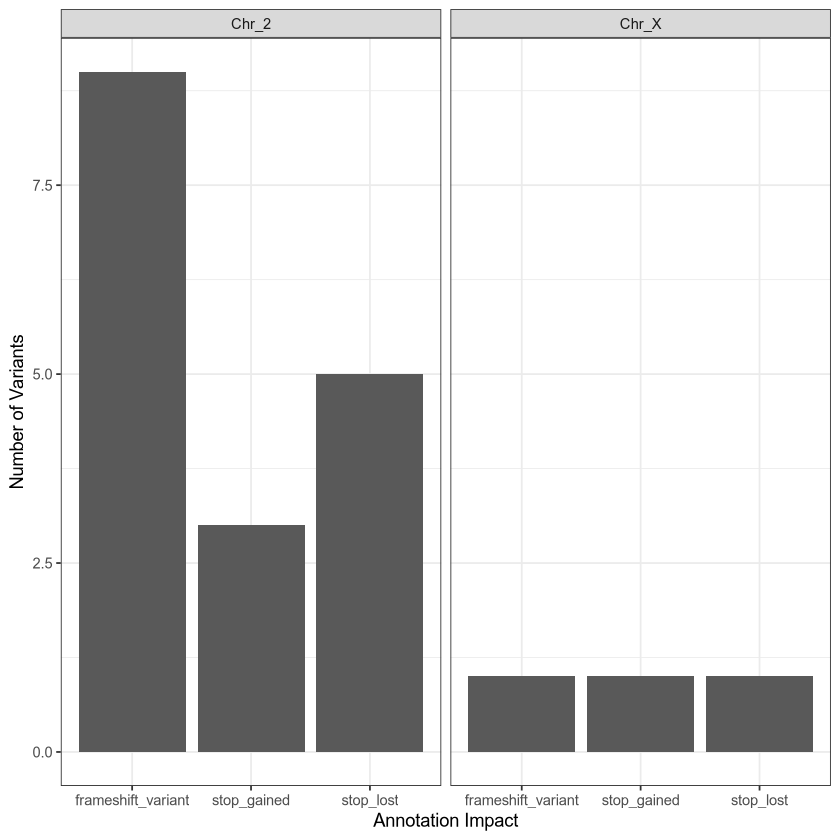

In [ ]:
## plot the impact of the SNPs in variants
inv_snpeff_bar <- inv_snpeff %>%
    select(number_chrom, pos, annotation_impact) %>%
    unique() %>%
    ggplot(aes(x = annotation_impact)) +
        geom_bar(count = "count") +
        labs(x = "Annotation Impact", y = "Number of Variants") +
        theme_bw() +
        facet_wrap(~ number_chrom)
inv_snpeff_bar

In [ ]:
ggsave("figures/inversion_snp_impact.png", inv_snpeff_bar, height = 12, width = 15)

In [ ]:
# ## create a bed file for the known inversions
# inversions_bed <- inversions %>%
#     select(number_chrom, start, end)
# colnames(inversions_bed) <- c("CHROM", "START", "END")
# head(inversions_bed)

In [ ]:
# write_tsv(inversions_bed, "input/inversion_flynn2023.bed")

In [ ]:
## load in all SNPs within inversions
inv_snp_raw <- read_tsv("input/inv_snp.vcf", col_names = FALSE)
colnames(inv_snp_raw) <- colnames(snpeff_raw)
head(inv_snp_raw)

Rows: 9887 Columns: 215
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (213): X1, X3, X4, X5, X7, X8, X9, X10, X11, X12, X13, X14, X15, X16, X1...
dbl   (2): X2, X6

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,pos,id,ref,alt,qual,filter,info,format,aa_99_06,⋯,wr_06_18,wr_06_22,wr_06_24,wr_06_40,wr_06_44,ws_07_06,ws_07_10,ws_07_16,ws_07_18,ws_07_20
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,635546,>34581>34583,C,CCCTTCT,6.53213,lowad,"DP=0;AT=>34581>34583,>34581>34582>34583;AF=0",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:0:0,0:-3.96506,-3.96506,-3.96506:0:-2.19723:9.12987:0",⋯,"0/0:0:0,0:-2.83702,-2.83702,-2.83702:0:-2.19723:6.53247:0","0/0:0:0,0:-4.01018,-4.01018,-4.01018:0:-2.19723:9.23377:0","0/0:0:0,0:-3.40668,-3.40668,-3.40668:0:-2.19723:7.84416:0","0/0:0:0,0:-4.20759,-4.20759,-4.20759:0:-2.19723:9.68831:0","0/0:0:0,0:-4.5742,-4.5742,-4.5742:0:-2.19723:10.5325:0","0/0:0:0,0:-3.49128,-3.49128,-3.49128:0:-2.19723:8.03896:0","0/0:0:0,0:-4.78289,-4.78289,-4.78289:0:-2.19723:11.013:0","0/0:0:0,0:-2.35196,-2.35196,-2.35196:0:-2.19723:5.41559:0","0/0:0:0,0:-3.21491,-3.21491,-3.21491:0:-2.19723:7.4026:0","0/0:0:0,0:-2.52117,-2.52117,-2.52117:0:-2.19723:5.80519:0"
Chr_2,635546,>34581>34583,C,CCCTTCT,6.53213,lowad,"DP=0;AT=>34581>34583,>34581>34582>34583;AF=0",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:0:0,0:-3.96506,-3.96506,-3.96506:0:-2.19723:9.12987:0",⋯,"0/0:0:0,0:-2.83702,-2.83702,-2.83702:0:-2.19723:6.53247:0","0/0:0:0,0:-4.01018,-4.01018,-4.01018:0:-2.19723:9.23377:0","0/0:0:0,0:-3.40668,-3.40668,-3.40668:0:-2.19723:7.84416:0","0/0:0:0,0:-4.20759,-4.20759,-4.20759:0:-2.19723:9.68831:0","0/0:0:0,0:-4.5742,-4.5742,-4.5742:0:-2.19723:10.5325:0","0/0:0:0,0:-3.49128,-3.49128,-3.49128:0:-2.19723:8.03896:0","0/0:0:0,0:-4.78289,-4.78289,-4.78289:0:-2.19723:11.013:0","0/0:0:0,0:-2.35196,-2.35196,-2.35196:0:-2.19723:5.41559:0","0/0:0:0,0:-3.21491,-3.21491,-3.21491:0:-2.19723:7.4026:0","0/0:0:0,0:-2.52117,-2.52117,-2.52117:0:-2.19723:5.80519:0"
Chr_2,635552,>34583>34585,T,TCCTTCC,6.53213,lowad,"DP=0;AT=>34583>34585,>34583>34584>34585;AF=0",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:0:0,0:-3.96506,-3.96506,-3.96506:0:-2.19723:9.12987:0",⋯,"0/0:0:0,0:-2.83702,-2.83702,-2.83702:0:-2.19723:6.53247:0","0/0:0:0,0:-4.01018,-4.01018,-4.01018:0:-2.19723:9.23377:0","0/0:0:0,0:-3.40668,-3.40668,-3.40668:0:-2.19723:7.84416:0","0/0:0:0,0:-4.20759,-4.20759,-4.20759:0:-2.19723:9.68831:0","0/0:0:0,0:-4.5742,-4.5742,-4.5742:0:-2.19723:10.5325:0","0/0:0:0,0:-3.49128,-3.49128,-3.49128:0:-2.19723:8.03896:0","0/0:0:0,0:-4.78289,-4.78289,-4.78289:0:-2.19723:11.013:0","0/0:0:0,0:-2.35196,-2.35196,-2.35196:0:-2.19723:5.41559:0","0/0:0:0,0:-3.21491,-3.21491,-3.21491:0:-2.19723:7.4026:0","0/0:0:0,0:-2.52117,-2.52117,-2.52117:0:-2.19723:5.80519:0"
Chr_2,635552,>34583>34585,T,TCCTTCC,6.53213,lowad,"DP=0;AT=>34583>34585,>34583>34584>34585;AF=0",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:0:0,0:-3.96506,-3.96506,-3.96506:0:-2.19723:9.12987:0",⋯,"0/0:0:0,0:-2.83702,-2.83702,-2.83702:0:-2.19723:6.53247:0","0/0:0:0,0:-4.01018,-4.01018,-4.01018:0:-2.19723:9.23377:0","0/0:0:0,0:-3.40668,-3.40668,-3.40668:0:-2.19723:7.84416:0","0/0:0:0,0:-4.20759,-4.20759,-4.20759:0:-2.19723:9.68831:0","0/0:0:0,0:-4.5742,-4.5742,-4.5742:0:-2.19723:10.5325:0","0/0:0:0,0:-3.49128,-3.49128,-3.49128:0:-2.19723:8.03896:0","0/0:0:0,0:-4.78289,-4.78289,-4.78289:0:-2.19723:11.013:0","0/0:0:0,0:-2.35196,-2.35196,-2.35196:0:-2.19723:5.41559:0","0/0:0:0,0:-3.21491,-3.21491,-3.21491:0:-2.19723:7.4026:0","0/0:0:0,0:-2.52117,-2.52117,-2.52117:0:-2.19723:5.80519:0"
Chr_2,635585,>34585>34588,T,C,45.86730,lowad;lowdepth,"DP=614;AT=>34585>34587>34588,>34585>34586>34588;AF=0.284314",GT:DP:AD:GL:GQ:GP:XD:MAD,"1/1:0:0,0:-4.51764,-4.51764,-4.51764:0:-2.19723:10.4022:0",⋯,"0/0:3:3,0:-1.87242,-2.69262,-8.6861:8:-1.23949:8.85754:3","0/0:6:6,0:-1.7151,-3.01613,-15.0031:13:-1.1474:9.98045:6","0/0:1:1,0:-2.54825,-3.19085,-5.18867:6:-1.30563:8.82682:1","1/1:0:0,0:-3.72548,-3.72548,-3.72548:0:-2.19723:8.57821:0","0/0:10:10,0:-1.78056,-4.18196,-24.1602:24:-1.10257:6.99441:10","0/0:11:11,0:-1.61692,-4.29254,-26.2686:26:-1.10072:12.3687:11","0/0:15:15,0:-2.5167,-6.10101,-36.0684:3

In [ ]:
inv_snp_raw %>%
    select(number_chrom, pos, alt) %>%
    unique() %>%
    group_by(number_chrom) %>%
    count() %>%
    rename(number_snps = n)

number_chrom,number_snps
<chr>,<int>
Chr_2,4514
Chr_4,123
Chr_5,320
Chr_X,3583
